# Brownlow 2025 Prediction
- Created by Jay Stein
- 3/9/22
- Purpose of this notebook is to make some awesome predictions for the upcoming Brownlow Medal

# Imports

## Standard Imports

In [192]:
import pandas as pd
import numpy as np

In [193]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.mode.chained_assignment = None

In [194]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [195]:
test_year = 2022

In [196]:
save_file = False
model_name = 'xgboost_brownlow_simple.json'
monte_carlo_name = 'bronwlon_mc_output_v1.csv'

## Imports for XGBoost

In [197]:
# from sklearnex import patch_sklearn
# patch_sklearn()
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import xgboost as xgb
import shap

# Read in data
- Got this using that super R library `fitzRoy`

In [198]:
#data from afl table
afltable = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\player_stats_2018_2025_fitzroy.csv", index_col=0)

C:\Users\mrjay\AppData\Local\Temp\ipykernel_38228\1989076876.py:2: DtypeWarning: Columns (50) have mixed types. Specify dtype option on import or set low_memory=False.
  afltable = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\player_stats_2018_2025_fitzroy.csv", index_col=0)


In [199]:
team_stats = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\team_stats_2018_2025_fitzroy.csv", index_col=0)

In [200]:
# read in Brownlow vote info
brownlow_votes = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\brownlow_stats_2018_2024_fitzroy.csv",
                             usecols=['Date','First.name','Surname','Playing.for','Brownlow.Votes'])
brownlow_votes['Date'] = pd.to_datetime(brownlow_votes['Date']).dt.date

## Data Normalization

In [201]:
def normal_cols(df):
    df.columns = df.columns.str.upper()
    df.columns = df.columns.str.replace(".","_")
    return df

In [202]:
afltable = normal_cols(afltable)
team_stats = normal_cols(team_stats)
brownlow_votes = normal_cols(brownlow_votes)

In [203]:
# get date of game
timeseries_utc = pd.to_datetime(afltable['UTCSTARTTIME'], utc=True)
local_dates = (timeseries_utc + pd.Timedelta(hours=10)).dt.date
afltable['GAME_DATE'] = local_dates

## Ensure no final rounds

In [204]:
afltable_filtered = afltable[~afltable['ROUND_NAME'].str.contains('Final')]

In [205]:
# add in full name for player
afltable_filtered['FULL_NAME'] = (afltable_filtered['PLAYER_GIVENNAME'] + ' ' + afltable_filtered['PLAYER_SURNAME']).str.upper()
brownlow_votes['FULL_NAME'] = (brownlow_votes['FIRST_NAME'] + ' ' + brownlow_votes['SURNAME']).str.upper()

In [206]:
afltable_filtered

,PROVIDERID,UTCSTARTTIME,STATUS,COMPSEASON_SHORTNAME,ROUND_NAME,ROUND_ROUNDNUMBER,VENUE_NAME,HOME_TEAM_NAME,HOME_TEAM_CLUB_NAME,AWAY_TEAM_NAME,AWAY_TEAM_CLUB_NAME,PLAYER_JUMPERNUMBER,PLAYER_PHOTOURL,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,PLAYER_PLAYER_PLAYER_CAPTAIN,PLAYER_PLAYER_PLAYER_PLAYERJUMPERNUMBER,PLAYER_PLAYER_PLAYER_GIVENNAME,PLAYER_PLAYER_PLAYER_SURNAME,TEAMID,GAMESPLAYED,TIMEONGROUNDPERCENTAGE,GOALS,BEHINDS,SUPERGOALS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,RANKING,LASTUPDATED,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,GOALEFFICIENCY,SHOTEFFICIENCY,INTERCHANGECOUNTS,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,EXTENDEDSTATS_CENTREBOUNCEATTENDANCES,EXTENDEDSTATS_KICKINS,EXTENDEDSTATS_KICKINSPLAYON,PLAYER_PLAYERID,PLAYER_CAPTAIN,PLAYER_PLAYERJUMPERNUMBER,PLAYER_GIVENNAME,PLAYER_SURNAME,TEAMSTATUS,EXTENDEDSTATS,TEAM_NAME,GAME_DATE,FULL_NAME
1,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,3,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,INT,CD_I291776,False,3,Taylor,Adams,CD_T160,NaN,54,1,0,NaN,4,4,8,3,0,0,3,6,9,2,1,0,0,0,75.0,3,0,1,32,0,1,100.0,3.4,NaN,NaN,4,0,0,1,NaN,NaN,NaN,2,106,0,1,1,3.0,75.0,1.0,6.0,2.0,0.0,33.3,0.0,0.0,0.0,3.0,1.0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD_I291776,False,3,Taylor,Adams,home,NaN,Sydney Swans,2025-03-07,TAYLOR ADAMS
2,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,36,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,FF,CD_I1008091,False,36,Joel,Amartey,CD_T160,NaN,82,3,1,NaN,7,4,11,4,0,2,5,6,11,0,1,0,1,1,72.7,0,2,0,71,0,0,75.0,11.8,NaN,NaN,1,2,1,4,NaN,NaN,NaN,5,229,0,0,0,5.0,71.4,1.8,8.0,1.0,1.0,45.5,0.0,16.7,0.0,3.0,0.0,0.0,8.0,4.0,1.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,0.0,CD_I1008091,False,36,Joel,Amartey,home,NaN,Sydney Swans,2025-03-07,JOEL AMARTEY
3,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,22,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,BPL,CD_I1006028,False,22,Nick,Blakey,CD_T160,NaN,87,1,0,NaN,21,5,26,3,4,0,6,9,15,1,0,0,0,6,80.8,4,2,0,90,13,0,100.0,22.4,NaN,NaN,4,8,0,1,NaN,NaN,NaN,3,804,0,0,0,16.0,76.2,4.2,21.0,0.0,1.0,40.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,1.0,6.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,CD_I1006028,False,22,Nick,Blakey,home,NaN,Sydney Swans,2025-03-07,NICK BLAKEY
4,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,16,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,HFFL,CD_I1013133,False,16,Braeden,Campbell,CD_T160,NaN,80,0,0,NaN,6,2,8,2,0,4,2,5,7,4,0,0,0,1,87.5,0,0,0,44,1,1,0.0,9.6,NaN,NaN,2,0,0,0,NaN,NaN,NaN,3,225,0,0,0,5.0,83.3,3.0,7.0,0.0,0.0,28.6,0.0,0.0,0.0,2.0,0.0,0.0,17.0,9.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,CD_I1013133,False,16,Braeden,Campb

## Check columns with NaN

In [207]:
nan_threshold = 0.05 # set threshold at 5%
afltable_filtered_nan = afltable_filtered.isna().mean().sort_values(ascending=False).to_frame('nan_pct')
nan_cols = afltable_filtered_nan.query("nan_pct > @nan_threshold").index.tolist()
print(f"The following columns will be dropped: {nan_cols}")

The following columns will be dropped: ['SUPERGOALS', 'INTERCHANGECOUNTS', 'RANKING', 'GAMESPLAYED', 'EXTENDEDSTATS', 'GOALEFFICIENCY', 'SHOTEFFICIENCY', 'LASTUPDATED', 'EXTENDEDSTATS_KICKINS', 'EXTENDEDSTATS_KICKINSPLAYON', 'EXTENDEDSTATS_CENTREBOUNCEATTENDANCES']


In [208]:
afltable_filtered = afltable_filtered.drop(columns=nan_cols)

## Minimal feature engineering

In [209]:
afltable_filtered = afltable_filtered.assign(PLAYER_POINTS = lambda x: x['GOALS']*6 + x['BEHINDS'])

# Combine Player with Team Statistics

In [210]:
team_cols_to_keep = ['MATCHID','ROUND_YEAR','HOMETEAMSCORE_MINUTESINFRONT','AWAYTEAMSCORE_MINUTESINFRONT','HOMETEAMSCORE_MATCHSCORE_TOTALSCORE','AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE']
team_stats_subset = team_stats.loc[:,team_cols_to_keep]

In [211]:
afltable_cols_to_keep = ['PROVIDERID','ROUND_ROUNDNUMBER','HOME_TEAM_NAME','PLAYER_PLAYER_POSITION','PLAYER_PLAYER_PLAYER_PLAYERID', 'GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS',
                         'TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50','CONTESTEDMARKS','HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY',
                         'RATINGPOINTS','TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL','SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES',
                         'EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_KICKEFFICIENCY','EXTENDEDSTATS_KICKTOHANDBALLRATIO','EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS',
                         'EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE','EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE','EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS',
                         'EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS','EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES','EXTENDEDSTATS_CONTESTDEFLOSSES',
                         'EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES','EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE','TEAM_NAME','FULL_NAME','PLAYER_POINTS','PLAYER_CAPTAIN','GAME_DATE']

In [212]:
afltable_subset = afltable_filtered.loc[:,afltable_cols_to_keep]

In [213]:
merged_df = afltable_subset.merge(team_stats_subset, how='inner', left_on='PROVIDERID', right_on='MATCHID')

# add in brownlow votes
merged_df = merged_df.merge(brownlow_votes, how='left', left_on=['GAME_DATE','FULL_NAME'], right_on=['DATE','FULL_NAME'])

In [214]:
# check it is working
merged_df.query("ROUND_YEAR == 2024").groupby(['FULL_NAME'])['BROWNLOW_VOTES'].sum().sort_values(ascending=False).head(5)

FULL_NAME
PATRICK CRIPPS    45.0
NICK DAICOS       38.0
ZAK BUTTERS       29.0
ISAAC HEENEY      28.0
CALEB SERONG      28.0
Name: BROWNLOW_VOTES, dtype: float64

## More minimal feature engineering

In [215]:
merged_df = (merged_df.
             assign(AT_HOME = lambda x: (x["HOME_TEAM_NAME"] == x["TEAM_NAME"]).astype(int),
                    PLAYERTEAMSCORE = lambda x: np.where(x['AT_HOME'] == 1, x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE'], x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE']),
                    PLAYER_MINUTESINFRONT = lambda x: np.where(x['AT_HOME'] == 1, x['HOMETEAMSCORE_MINUTESINFRONT'], x['AWAYTEAMSCORE_MINUTESINFRONT']),
                    PLAYERTEAM_MARGIN = lambda x: np.where(x['AT_HOME'] == 1, 
                                                           x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE'] -  x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE'],
                                                           x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE'] -  x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE']
                                                           ),
                    PLAYERTEAM_OUTCOME = lambda x: np.where(
                        x['PLAYERTEAM_MARGIN'] > 0, 'WIN',
                        np.where(x['PLAYERTEAM_MARGIN'] == 0, 'DRAW','LOSE'))           
             ))

## Add in team proportions

In [216]:
proportion_features = ['GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS','TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50',
                       'CONTESTEDMARKS','HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY','RATINGPOINTS',
                       'TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL','SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES',
                       'EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE',
                       'EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE','EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS',
                       'EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS','EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES',
                       'EXTENDEDSTATS_CONTESTDEFLOSSES','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES','EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE']

In [217]:
proportion_values = merged_df.groupby(['PROVIDERID','TEAM_NAME'])[proportion_features].transform(lambda x: x/x.sum())
proportion_values = proportion_values.fillna(0) #fill in NaN

In [218]:
proportion_labels = [col + "_prop" for col in proportion_values.columns] #make some nice labels
proportion_values.columns = proportion_labels #assign new labels

In [219]:
afltable_merged = pd.concat([merged_df, proportion_values], axis=1)

# Do this to backcast

In [220]:
# filter to remove the test year
#afltable_merged = afltable_merged[~afltable_merged['ROUND_YEAR'].isin([test_year, 2025])]

In [221]:
afltable_merged.head()

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop
0,CD_M20250140002,0,Sydney Swans,INT,CD_I291776,1,0,4,4,8,3,0,0,3,6,9,2,1,0,0,0,75.0,3,0,1,32,0,1,100.0,3.4,4,0,0,1,2,106,0,1,1,3.0,75.0,1.0,6.0,2.0,0.0,33.3,0.0,0.0,0.0,3.0,1.0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sydney Swans,TAYLOR ADAMS,6,False,2025-03-07,CD_M20250140002,2025,15,112,76,96,NaN,NaN,NaN,NaN,NaN,1,76,15,-20,LOSE,0.090909,0.000000,0.019704,0.033898,0.024922,0.042254,0.000000,0.000000,0.024793,0.033333,0.029900,0.050,0.2,0.0,0.00000,0.000000,0.044757,0.050000,0.000000,0.043478,0.023881,0.000000,0.142857,0.16,0.019058,0.064516,0.000000,0.0,0.05,0.023529,0.019283,0.0,0.047619,0.030303,0.022222,0.025641,0.285714,0.000000,0.035516,0.0,0.000000,0.0,0.034884,0.083333,0.000000,0.026022,0.006494,0.000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
1,CD_M20250140002,0,Sydney Swans,FF,CD_I1008091,3,1,7,4,11,4,0,2,5,6,11,0,1,0,1,1,72.7,0,2,0,71,0,0,75.0,11.8,1,2,1,4,5,229,0,0,0,5.0,71.4,1.8,8.0,1.0,1.0,45.5,0.0,16.7,0.0,3.0,0.0,0.0,8.0,4.0,1.0,6.0,0

In [222]:
feature_list = ['PLAYER_PLAYER_POSITION','GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS','TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50','CONTESTEDMARKS',
                'HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY','RATINGPOINTS','TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL',
                'SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES','EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_KICKEFFICIENCY','EXTENDEDSTATS_KICKTOHANDBALLRATIO',
                'EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE','EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE',
                'EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS','EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS',
                'EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES','EXTENDEDSTATS_CONTESTDEFLOSSES','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES',
                'EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE','PLAYER_POINTS','PLAYER_CAPTAIN','AT_HOME','PLAYERTEAMSCORE','PLAYER_MINUTESINFRONT','PLAYERTEAM_MARGIN','PLAYERTEAM_OUTCOME',
                'GOALS_prop','BEHINDS_prop','KICKS_prop','HANDBALLS_prop','DISPOSALS_prop','MARKS_prop','BOUNCES_prop','TACKLES_prop','CONTESTEDPOSSESSIONS_prop','UNCONTESTEDPOSSESSIONS_prop','TOTALPOSSESSIONS_prop',
                'INSIDE50S_prop','MARKSINSIDE50_prop','CONTESTEDMARKS_prop','HITOUTS_prop','ONEPERCENTERS_prop','DISPOSALEFFICIENCY_prop','CLANGERS_prop','FREESFOR_prop','FREESAGAINST_prop','DREAMTEAMPOINTS_prop',
                'REBOUND50S_prop','GOALASSISTS_prop','GOALACCURACY_prop','RATINGPOINTS_prop','TURNOVERS_prop','INTERCEPTS_prop','TACKLESINSIDE50_prop','SHOTSATGOAL_prop','SCOREINVOLVEMENTS_prop','METRESGAINED_prop',
                'CLEARANCES_CENTRECLEARANCES_prop','CLEARANCES_STOPPAGECLEARANCES_prop','CLEARANCES_TOTALCLEARANCES_prop','EXTENDEDSTATS_EFFECTIVEKICKS_prop','EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop','EXTENDEDSTATS_MARKSONLEAD_prop',
                'EXTENDEDSTATS_INTERCEPTMARKS_prop','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop','EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop','EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop','EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop',
                'EXTENDEDSTATS_GROUNDBALLGETS_prop','EXTENDEDSTATS_F50GROUNDBALLGETS_prop','EXTENDEDSTATS_SCORELAUNCHES_prop','EXTENDEDSTATS_PRESSUREACTS_prop','EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop','EXTENDEDSTATS_SPOILS_prop',
                'EXTENDEDSTATS_RUCKCONTESTS_prop','EXTENDEDSTATS_CONTESTDEFONEONONES_prop','EXTENDEDSTATS_CONTESTDEFLOSSES_prop','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop','EXTENDEDSTATS_CONTESTOFFONEONONES_prop',
                'EXTENDEDSTATS_CONTESTOFFWINS_prop','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop']

In [223]:
X_afl_all = afltable_merged.reset_index(drop=True)
y_afl_all = afltable_merged['BROWNLOW_VOTES'].reset_index(drop=True) #remember nothing yet assigned for 2025 season train on 2018-2024

## Create reference tables player id and game id

In [224]:
player_id = afltable_merged[['PLAYER_PLAYER_PLAYER_PLAYERID','FULL_NAME']].drop_duplicates().reset_index(drop=True) #retain for reference
player_id = player_id.rename(columns={'PLAYER_PLAYER_PLAYER_PLAYERID':'PLAYER_ID'})
player_id = player_id.set_index('PLAYER_ID')
player_id['PLAYER_ID'] = player_id.index

In [225]:
game_id_df = afltable_merged[['ROUND_YEAR','ROUND_ROUNDNUMBER','MATCHID']].drop_duplicates()
game_id_df = game_id_df.reset_index(drop=True)
game_id_df['GAME_ID'] = game_id_df.index

# Use all training data

In [226]:
X_afl_train = X_afl_all[~X_afl_all['ROUND_YEAR'].isin([test_year, 2025])] # drop the test year and 2025
X_afl_test = X_afl_all.query(f"ROUND_YEAR == {test_year}")
y_afl_train = y_afl_all.loc[X_afl_train.index]

In [227]:
len(X_afl_train)

52349

In [228]:
len(y_afl_train)

52349

# Check if we have all the BROWNLOW VOTES
- for previous years

In [229]:
brownlow_total_check = afltable_merged.groupby(['FULL_NAME','TEAM_NAME','ROUND_YEAR'])['BROWNLOW_VOTES'].sum().unstack(['ROUND_YEAR'])

In [230]:
brownlow_total_check

ROUND_YEAR                       2018  2019  2020  2021  2022  2023  2024  2025
FULL_NAME     TEAM_NAME                                                        
AARON BLACK   Geelong Cats        0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
              West Coast Eagles   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN
AARON CADMAN  GWS GIANTS          NaN   NaN   NaN   NaN   NaN   0.0   0.0   0.0
AARON FRANCIS Essendon            0.0   0.0   0.0   0.0   0.0   NaN   NaN   NaN
              Sydney Swans        NaN   NaN   NaN   NaN   NaN   0.0   0.0   0.0
...                               ...   ...   ...   ...   ...   ...   ...   ...
ZAK JOHNSON   Essendon            NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.0
ZAK JONES     St Kilda            NaN   NaN   7.0   4.0   0.0   0.0   1.0   0.0
              Sydney Swans        0.0   0.0   NaN   NaN   NaN   NaN   NaN   NaN
ZANE DUURSMA  North Melbourne     NaN   NaN   NaN   NaN   NaN   NaN   0.0   0.0
ZANE TREW     West Coast Eagles   NaN   NaN   NaN   NaN   0.0   0.0   0.0   NaN

[1594 rows x 8 columns]

In [231]:
years = [int(y) for y in range(2018, 2025)]
rows = []

for yr in years:
    s = brownlow_total_check[yr].nlargest(5)  # Series: index -> value, ignores NaN
    idxs = list(s.index)
    vals = list(s.values)
    # pad to length 5
    while len(idxs) < 5:
        idxs.append(pd.NA)
        vals.append(pd.NA)
    rows.append({
        'year': yr,
        'top1_name': idxs[0], 'top1_value': vals[0],
        'top2_name': idxs[1], 'top2_value': vals[1],
        'top3_name': idxs[2], 'top3_value': vals[2],
        'top4_name': idxs[3], 'top4_value': vals[3],
        'top5_name': idxs[4], 'top5_value': vals[4],
    })

top5_df = pd.DataFrame(rows).set_index('year')

In [232]:
top5_df

,top1_name,top1_value,top2_name,top2_value,top3_name,top3_value,top4_name,top4_value,top5_name,top5_value
year,,,,,,,,,,
2018,"(TOM MITCHELL, Hawthorn)",28.0,"(STEELE SIDEBOTTOM, Collingwood)",24.0,"(ANGUS BRAYSHAW, Melbourne)",21.0,"(MAX GAWN, Melbourne)",20.0,"(PATRICK CRIPPS, Carlton)",20.0
2019,"(NAT FYFE, Fremantle)",33.0,"(PATRICK DANGERFIELD, Geelong Cats)",27.0,"(LACHIE NEALE, Brisbane Lions)",26.0,"(PATRICK CRIPPS, Carlton)",26.0,"(TIM KELLY, Geelong Cats)",24.0
2020,"(LACHIE NEALE, Brisbane Lions)",31.0,"(TRAVIS BOAK, Port Adelaide)",21.0,"(CHRISTIAN PETRACCA, Melbourne)",20.0,"(JACK STEELE, St Kilda)",20.0,"(DUSTIN MARTIN, Richmond)",15.0
2021,"(OLLIE WINES, Port Adelaide)",36.0,"(MARCUS BONTEMPELLI, Western Bulldogs)",33.0,"(CLAYTON OLIVER, Melbourne)",31.0,"(SAM WALSH, Carlton)",30.0,"(DARCY PARISH, Essendon)",26.0
2022,"(PATRICK CRIPPS, Carlton)",29.0,"(LACHIE NEALE, Brisbane Lions)",28.0,"(TOUK MILLER, Gold Coast SUNS)",27.0,"(ANDREW BRAYSHAW, Fremantle)",25.0,"(CLAYTON OLIVER, Melbourne)",25.0
2023,"(LACHIE NEALE, Brisbane Lions)",31.0,"(MARCUS BONTEMPELLI, Western Bulldogs)",29.0,"(NICK DAICOS, Collingwood)",28.0,"(ERROL GULDEN, Sydney Swans)",27.0,"(ZAK BUTTERS, Port Adelaide)",27.0
2024,"(PATRICK CRIPPS, Carlton)",45.0,"(NICK DAICOS, Collingwood)",38.0,"(ZAK BUTTERS, Port Adelaide)",29.0,"(CALEB SERONG, Fremantle)",28.0,"(ISAAC HEENEY, Sydney Swans)",28.0


# Prepare for ML

In [233]:
# map the categorical cols
cat_cols = ['PLAYER_PLAYER_POSITION', 'PLAYERTEAM_OUTCOME']

In [234]:
for c in cat_cols:
    X_afl_train[c] = X_afl_train[c].astype('category')
    X_afl_test[c] = X_afl_test[c].astype('category')

In [235]:
# very small number of NaN..... we can just fill them with mean
X_afl_train[feature_list].isna().sum().sort_values(ascending=False)

EXTENDEDSTATS_KICKEFFICIENCY                   5
EXTENDEDSTATS_CONTESTDEFLOSSES                 5
EXTENDEDSTATS_RUCKCONTESTS                     5
EXTENDEDSTATS_SPOILS                           5
EXTENDEDSTATS_DEFHALFPRESSUREACTS              5
EXTENDEDSTATS_PRESSUREACTS                     5
RATINGPOINTS                                   5
EXTENDEDSTATS_SCORELAUNCHES                    5
EXTENDEDSTATS_F50GROUNDBALLGETS                5
EXTENDEDSTATS_GROUNDBALLGETS                   5
EXTENDEDSTATS_HITOUTTOADVANTAGERATE            5
EXTENDEDSTATS_HITOUTWINPERCENTAGE              5
EXTENDEDSTATS_HITOUTSTOADVANTAGE               5
EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE          5
EXTENDEDSTATS_INTERCEPTMARKS                   5
EXTENDEDSTATS_MARKSONLEAD                      5
EXTENDEDSTATS_EFFECTIVEKICKS                   5
EXTENDEDSTATS_CONTESTDEFONEONONES              5
EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE         5
EXTENDEDSTATS_KICKTOHANDBALLRATIO              5
EXTENDEDSTATS_CONTES

In [236]:
X_afl_test[feature_list].isna().sum().sort_values(ascending=False)

PLAYER_PLAYER_POSITION                         0
GOALS                                          0
GOALACCURACY_prop                              0
GOALASSISTS_prop                               0
REBOUND50S_prop                                0
DREAMTEAMPOINTS_prop                           0
FREESAGAINST_prop                              0
FREESFOR_prop                                  0
CLANGERS_prop                                  0
DISPOSALEFFICIENCY_prop                        0
ONEPERCENTERS_prop                             0
HITOUTS_prop                                   0
CONTESTEDMARKS_prop                            0
MARKSINSIDE50_prop                             0
INSIDE50S_prop                                 0
TOTALPOSSESSIONS_prop                          0
UNCONTESTEDPOSSESSIONS_prop                    0
CONTESTEDPOSSESSIONS_prop                      0
TACKLES_prop                                   0
BOUNCES_prop                                   0
MARKS_prop          

In [237]:
X_afl_train[feature_list].shape

(52349, 120)

In [238]:
numeric_features = X_afl_train[feature_list].select_dtypes(include=['number']).columns.tolist()

In [239]:
numeric_features_means = X_afl_train[numeric_features].mean()
numeric_features_test_means = X_afl_test[numeric_features].mean()

In [240]:
# fill in the NaN
X_afl_train[numeric_features] = X_afl_train[numeric_features].fillna(numeric_features_means)
X_afl_test[numeric_features] = X_afl_test[numeric_features].fillna(numeric_features_test_means)

In [241]:
X_afl_train[feature_list].isna().sum().sum()

0

In [242]:
y_afl_train.isna().sum().sum()

1601

In [243]:
# there are some null with brownlow votes - we can safely fill them with 0
y_afl_train = y_afl_train.fillna(0)

# Time for magic!

In [244]:
data_matrix = xgb.DMatrix(data=X_afl_train[feature_list], label=y_afl_train, enable_categorical=True)

In [245]:
# CV choices
nfold = 10            # choose 5 (faster). Use 10 if you want lower variance and more compute.
seed = 42
num_boost_round = 3000
early_stopping_rounds = 100

In [246]:
# baseline params (simple, conservative baseline)
params_baseline = {
    'objective': 'reg:pseudohubererror',
    'eval_metric': 'mae',
    'verbosity': 1,
    'learning_rate': 0.05,    # reasonable default for baseline
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    # no heavy regularization here — this is a baseline
}

In [247]:
print("Running xgb.cv baseline (this can take a while)...")
cv_results = xgb.cv(
    params=params_baseline,
    dtrain=data_matrix,
    num_boost_round=num_boost_round,
    nfold=nfold,
    early_stopping_rounds=early_stopping_rounds,
    metrics='mae',
    seed=seed,
    as_pandas=True,
    stratified=False,
    verbose_eval=50
)

Running xgb.cv baseline (this can take a while)...
[0]	train-mae:0.17538+0.00124	test-mae:0.17637+0.00743
[50]	train-mae:0.10022+0.00050	test-mae:0.12262+0.00488
[100]	train-mae:0.08946+0.00075	test-mae:0.11971+0.00472
[150]	train-mae:0.08454+0.00093	test-mae:0.12035+0.00461
[200]	train-mae:0.08041+0.00089	test-mae:0.12117+0.00449
[203]	train-mae:0.08018+0.00088	test-mae:0.12121+0.00449


In [248]:
best_round = len(cv_results)
best_test_mae = cv_results['test-mae-mean'].min()
print(f"\nCV complete. best_round={best_round}, best test MAE={best_test_mae:.6f}")


CV complete. best_round=104, best test MAE=0.119669


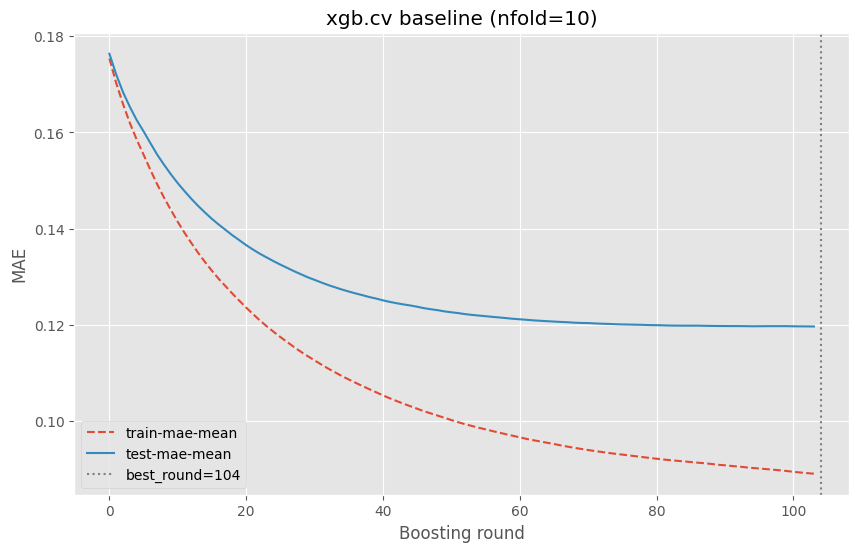

In [249]:
# Plot mean MAE curves
plt.figure(figsize=(10,6))
plt.plot(cv_results['train-mae-mean'], linestyle='--', label='train-mae-mean')
plt.plot(cv_results['test-mae-mean'], label='test-mae-mean')
plt.axvline(best_round, color='gray', linestyle=':', label=f'best_round={best_round}')
plt.xlabel('Boosting round')
plt.ylabel('MAE')
plt.title(f'xgb.cv baseline (nfold={nfold})')
plt.legend()
plt.grid(True)
plt.show()

In [250]:
# make the model
bst_final = xgb.train(
    dict(params_baseline), 
    data_matrix, num_boost_round=best_round, verbose_eval=10
)

In [251]:
if save_file:
    bst_final.save_model(f'../models/{model_name}')

In [252]:
importance_gain = bst_final.get_score(importance_type='gain')
importance_wt = bst_final.get_score(importance_type='weight')

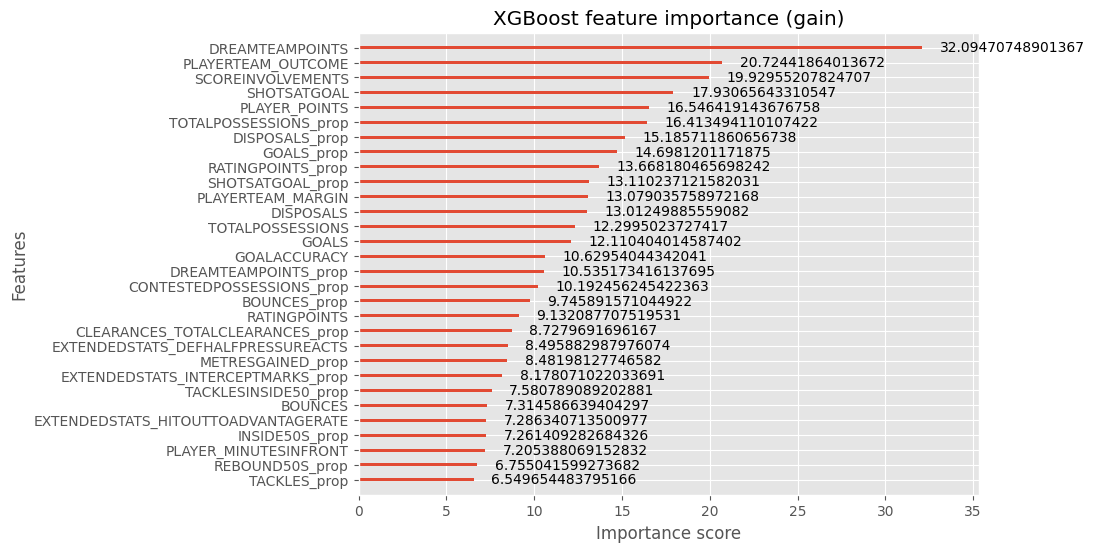

In [253]:
fig, ax = plt.subplots(figsize=(8,6))
xgb.plot_importance(bst_final, importance_type='gain', max_num_features=30, ax=ax)
ax.set_title("XGBoost feature importance (gain)")
plt.show()

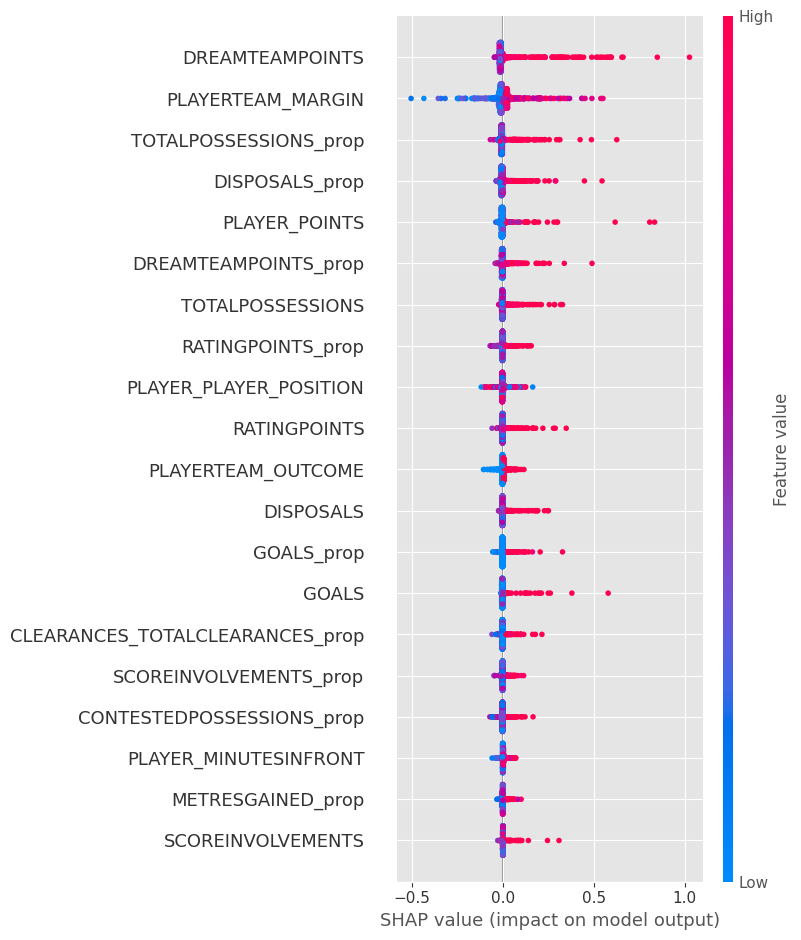

In [254]:
# copy data to avoid mutating original
X_shap = X_afl_train[feature_list].copy()
# find categorical columns (pandas 'category' dtype)
cat_cols = X_shap.select_dtypes(include=['category']).columns.tolist()
# save mappings if you want to reverse codes later
cat_mappings = {}
for c in cat_cols:
    # use codes but preserve a mapping from code -> category value
    cats = X_shap[c].cat.categories
    cat_mappings[c] = dict(enumerate(cats))
    X_shap[c] = X_shap[c].cat.codes.replace({-1: pd.NA})  # -1 is pandas code for NaN
# optionally fill any remaining NaNs in numeric columns (SHAP needs finite values)
X_shap = X_shap.fillna(0)
# sample if large
X_sample = X_shap.sample(n=min(1000, len(X_shap)), random_state=42)

# 1) Create TreeExplainer from the Booster
explainer = shap.TreeExplainer(bst_final)   # handles xgb.Booster directly

# 2) compute shap values (returns array shaped (n_samples, n_features))
shap_values = explainer.shap_values(X_sample)   # for regression this is 2D

# 3) summary plot (global)
shap.summary_plot(shap_values, X_sample, plot_type="dot")  # beeswarm

# Make backcast Prediction

In [255]:
# 8) predict on new data (make DMatrix the same way)
dtest = xgb.DMatrix(X_afl_test[feature_list], enable_categorical=True)
y_pred = bst_final.predict(dtest)

In [256]:
brownlow_pred_series = pd.Series(y_pred,name='BROWNLOW_FLOAT_PREDICTION')
full_df_pred = pd.concat([X_afl_test.reset_index(drop=True), 
                          brownlow_pred_series], axis=1)

In [257]:
full_df_pred[(full_df_pred['ROUND_ROUNDNUMBER'] == 24) ].sort_values(by='BROWNLOW_FLOAT_PREDICTION', ascending=False).head(10)

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop,BROWNLOW_FLOAT_PREDICTION


# Rank and score for each game

In [258]:
full_df_pred['BROWNLOW_RANK'] = (full_df_pred
                                 .groupby(['MATCHID'])['BROWNLOW_FLOAT_PREDICTION']
                                 .rank(method='min', ascending=False)) # the method just means a tie gets the lowest rank value like a tie for top both get a 1

In [259]:
rank_series = full_df_pred['BROWNLOW_RANK'].astype(float)

full_df_pred['BROWNLOW_POINTS'] = np.select(
    condlist=[rank_series == 1, rank_series == 2, rank_series == 3],
    choicelist=[3,2,1],
    default=0
).astype(int)

In [260]:
# monte carlo output
mc_output_cols = ['FULL_NAME','TEAM_NAME','ROUND_ROUNDNUMBER','MATCHID','BROWNLOW_FLOAT_PREDICTION']

if save_file:
    full_df_pred[mc_output_cols].to_csv(f'../result/{monte_carlo_name}', index=False)

# Summary Stats

In [261]:
votes_by_player = full_df_pred.groupby(['FULL_NAME','TEAM_NAME'])['BROWNLOW_POINTS'].sum()
votes_by_player = votes_by_player.sort_values(ascending=False).reset_index()

In [262]:
max_votes_idx = votes_by_player.groupby('TEAM_NAME')['BROWNLOW_POINTS'].idxmax()
votes_by_team = votes_by_player.loc[max_votes_idx].reset_index(drop=True)
votes_by_team

,FULL_NAME,TEAM_NAME,BROWNLOW_POINTS
0,RORY LAIRD,Adelaide Crows,22
1,LACHIE NEALE,Brisbane Lions,30
2,PATRICK CRIPPS,Carlton,30
3,JACK CRISP,Collingwood,13
4,ZACH MERRETT,Essendon,20
5,ANDREW BRAYSHAW,Fremantle,24
6,JOSH KELLY,GWS GIANTS,11
7,JEREMY CAMERON,Geelong Cats,19
8,TOUK MILLER,Gold Coast SUNS,27
9,TOM MITCHELL,Hawthorn,13


In [263]:
player_check = 'JACK GUNSTON'
player_check_by_round = (full_df_pred
                         .query(f"FULL_NAME == '{player_check}'")
                         .groupby(['ROUND_ROUNDNUMBER'])[['BROWNLOW_FLOAT_PREDICTION','BROWNLOW_POINTS']]
                         .sum())

display(player_check_by_round)

,BROWNLOW_FLOAT_PREDICTION,BROWNLOW_POINTS
ROUND_ROUNDNUMBER,,
1,0.815774,3
2,0.059356,0
3,0.002396,0
4,-0.000234,0
5,0.146231,0
6,0.001937,0
7,0.001188,0
8,0.005716,0
9,-0.000234,0


In [264]:
(votes_by_player
 .sort_values('BROWNLOW_POINTS', ascending=False).head(10)
 .assign(SEASON = test_year)
).to_csv(f'../backcast/run_for_{test_year}.csv', index=False)